# Installing Libraries

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.1 MB/s eta 0:00:00


In [ ]:
!pip install datasets transformers nltk wordcloud textblob seaborn scikit-learn -q

In [ ]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import string
from wordcloud import WordCloud
from textblob import TextBlob
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# loading data

In [ ]:
dataset = load_dataset("NickyNicky/drugsComTest_raw")
df = dataset['train'].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/837 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/53766 [00:00<?, ? examples/s]

In [ ]:
df.head()

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10.0,"February 28, 2012",22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8.0,"May 17, 2009",17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9.0,"September 29, 2017",3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9.0,"March 5, 2017",35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9.0,"October 22, 2015",4


In [ ]:
print("Shape:", df.shape)

Shape: (53766, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   53766 non-null  int64  
 1   drugName     53766 non-null  object 
 2   condition    53471 non-null  object 
 3   review       53766 non-null  object 
 4   rating       53766 non-null  float64
 5   date         53766 non-null  object 
 6   usefulCount  53766 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 2.9+ MB


In [ ]:
# checking missing values
df.isnull().sum()

,0
Unnamed: 0,0
drugName,0
condition,295
review,0
rating,0
date,0
usefulCount,0


In [ ]:
# Handling missing values
df['condition'] = df['condition'].fillna('Unknown')

In [ ]:
# checking missing values
df.isnull().sum()

,0
Unnamed: 0,0
drugName,0
condition,0
review,0
rating,0
date,0
usefulCount,0


#Text Cleaning

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 7 else 0)

# EDA

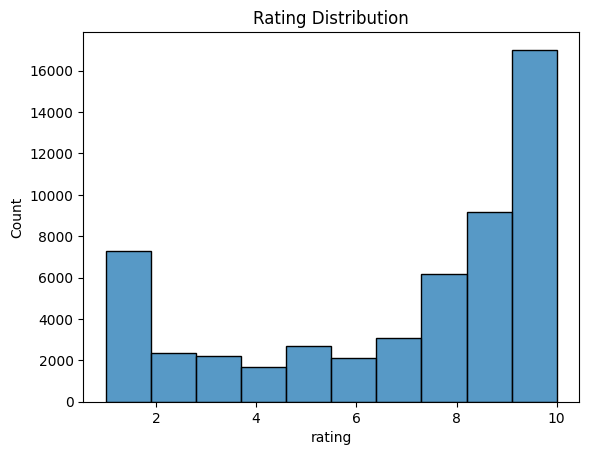

In [ ]:
# Rating Distribution
plt.figure()
sns.histplot(df['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

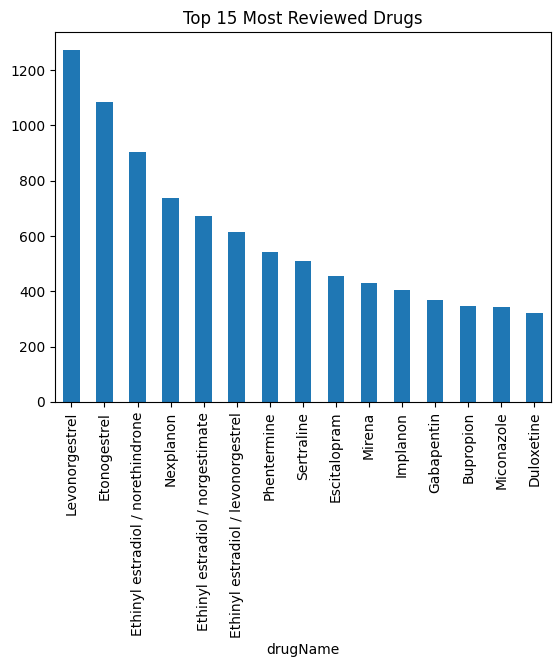

In [ ]:
# Top 15 Drugs
top_drugs = df['drugName'].value_counts().head(15)
plt.figure()
top_drugs.plot(kind='bar')
plt.title("Top 15 Most Reviewed Drugs")
plt.show()

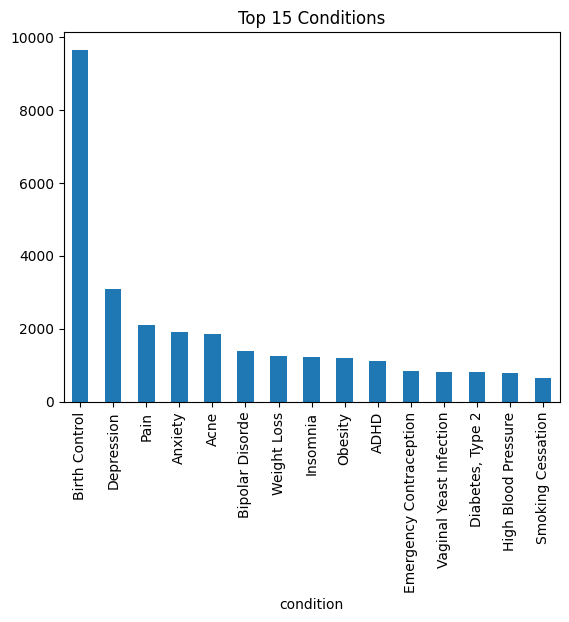

In [ ]:
#Top 15 Conditions
top_conditions = df['condition'].value_counts().head(15)
plt.figure()
top_conditions.plot(kind='bar')
plt.title("Top 15 Conditions")
plt.show()

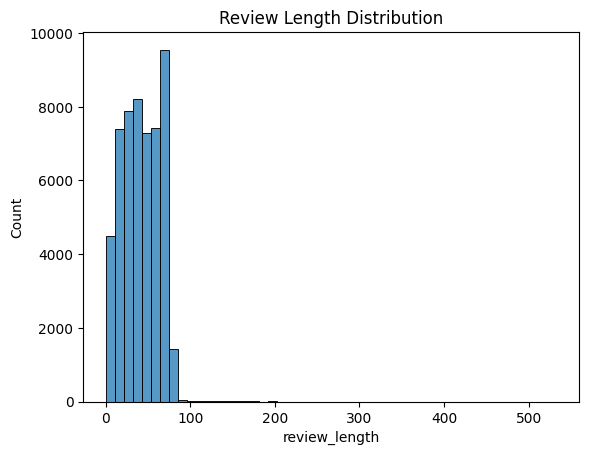

In [ ]:
#Review Length Distribution
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))
plt.figure()
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

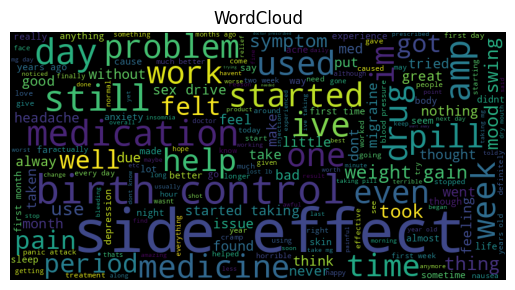

In [ ]:
# WordCloud
wordcloud = WordCloud(width=800, height=400).generate(" ".join(df['clean_review']))
plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud")
plt.show()

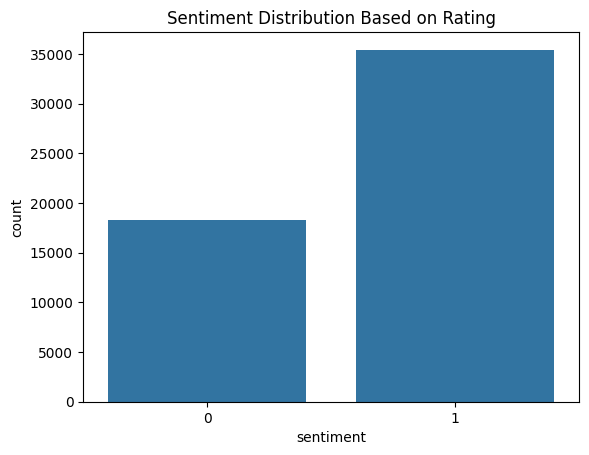

In [ ]:
# Positive vs Negative Rating Count
df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 7 else 0)
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution Based on Rating")
plt.show()

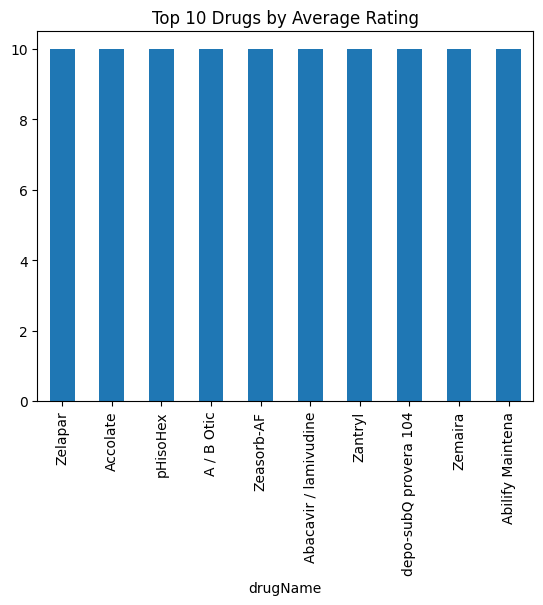

In [ ]:
# Average Rating per Top 10 Drugs
avg_rating = df.groupby('drugName')['rating'].mean().sort_values(ascending=False).head(10)
plt.figure()
avg_rating.plot(kind='bar')
plt.title("Top 10 Drugs by Average Rating")
plt.show()

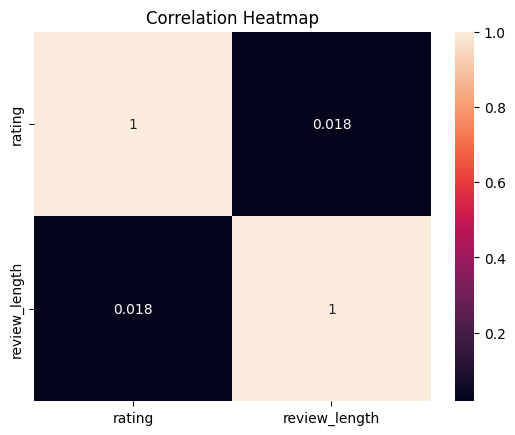

In [ ]:
# Correlation Heatmap
plt.figure()
sns.heatmap(df[['rating','review_length']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

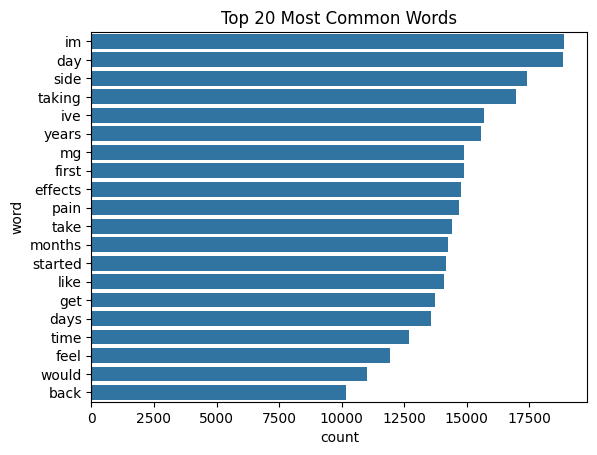

In [ ]:
# Most Common Words
from collections import Counter
words = " ".join(df['clean_review']).split()
common_words = Counter(words).most_common(20)
common_df = pd.DataFrame(common_words, columns=['word','count'])

plt.figure()
sns.barplot(x='count', y='word', data=common_df)
plt.title("Top 20 Most Common Words")
plt.show()

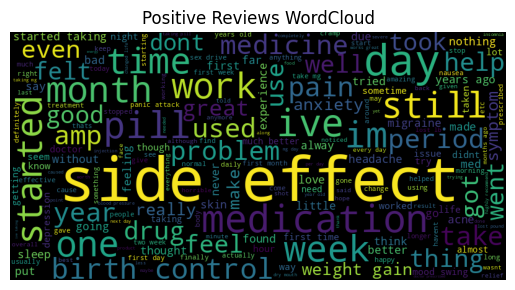

In [ ]:
# Sentiment WordCloud positive
pos_text = " ".join(df[df['sentiment']==1]['clean_review'])
wordcloud = WordCloud(width=800, height=400).generate(pos_text)
plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

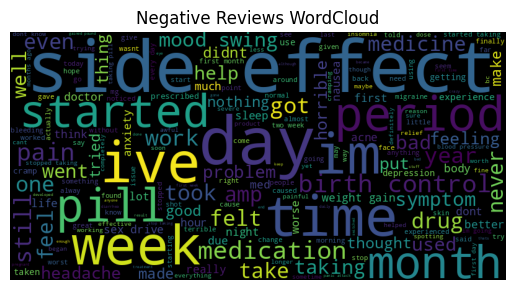

In [ ]:
# Sentiment WordCloud Negative
neg_text = " ".join(df[df['sentiment']==0]['clean_review'])
wordcloud = WordCloud(width=800, height=400).generate(neg_text)
plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

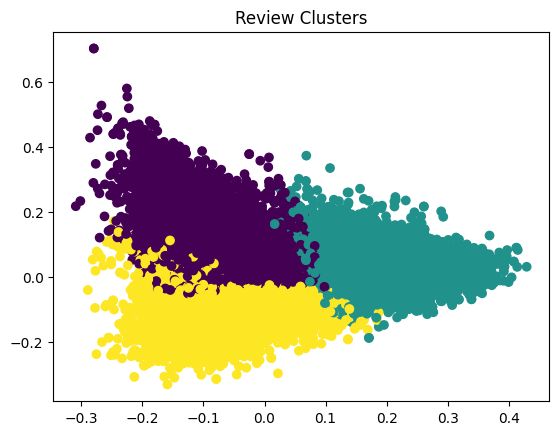

In [ ]:
# KMeans Clustering Visualization
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_review'])

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

plt.figure()
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=df['cluster'])
plt.title("Review Clusters")
plt.show()

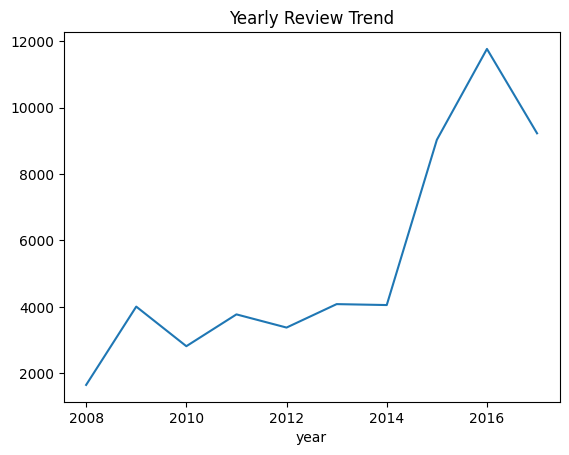

In [ ]:
# Monthly Review Trend
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
yearly = df['year'].value_counts().sort_index()

plt.figure()
yearly.plot()
plt.title("Yearly Review Trend")
plt.show()

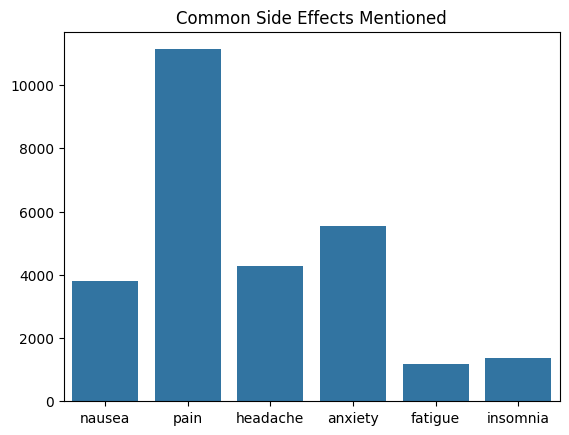

In [ ]:
# Top Side Effect Keywords
side_effect_keywords = ['nausea','pain','headache','anxiety','fatigue','insomnia']
counts = {}

for word in side_effect_keywords:
    counts[word] = df['clean_review'].str.contains(word).sum()

plt.figure()
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title("Common Side Effects Mentioned")
plt.show()

# Building NLP Sentiment Model

In [ ]:
#Train-Test-Split
X = df['clean_review']
y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# TF-IDF and Logistic Regression
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model_lr.predict(X_test_tfidf)

In [ ]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8156964850288265


In [ ]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.65      0.71      3679
           1       0.83      0.90      0.87      7075

    accuracy                           0.82     10754
   macro avg       0.80      0.77      0.79     10754
weighted avg       0.81      0.82      0.81     10754



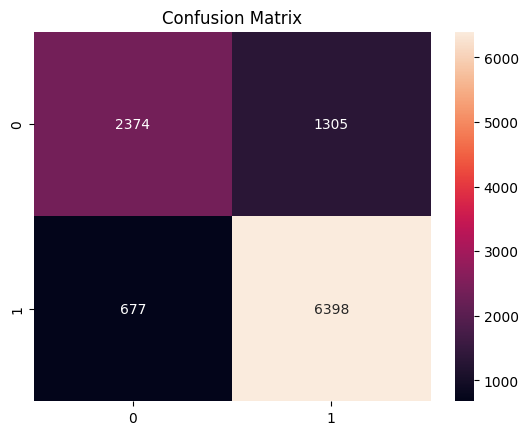

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

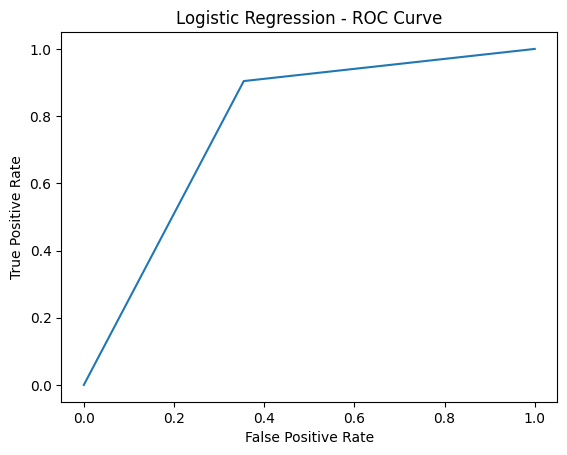

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
plt.figure()
plt.plot(fpr, tpr)
plt.title("Logistic Regression - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

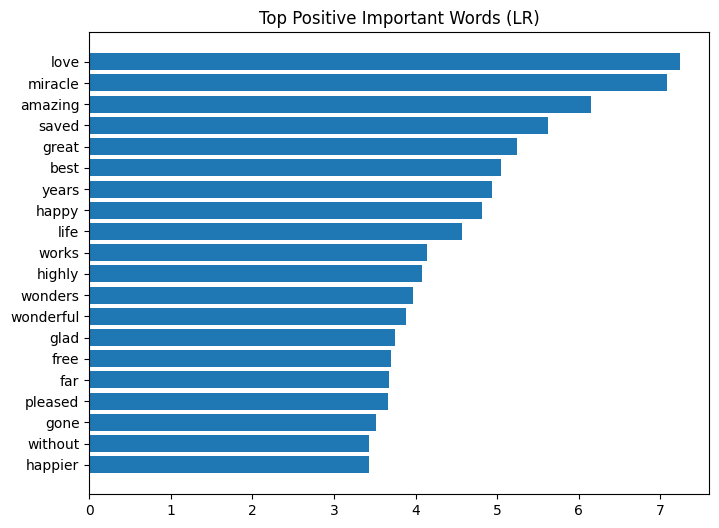

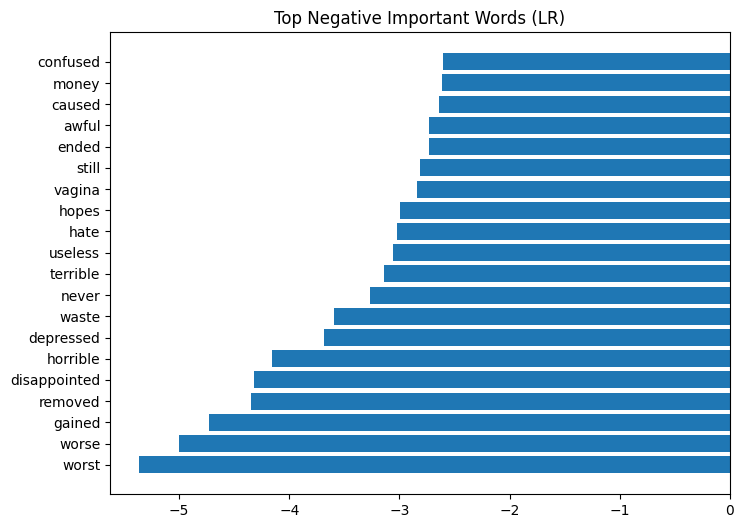

In [ ]:
feature_names = vectorizer.get_feature_names_out()

coefs = model_lr.coef_[0]
top_pos = np.argsort(coefs)[-20:]
top_neg = np.argsort(coefs)[:20]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_pos], coefs[top_pos])
plt.title("Top Positive Important Words (LR)")
plt.show()

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_neg], coefs[top_neg])
plt.title("Top Negative Important Words (LR)")
plt.show()

In [ ]:
# Support Vector Machine
svm = LinearSVC()
model_svm = CalibratedClassifierCV(svm)
model_svm.fit(X_train_tfidf, y_train)

CalibratedClassifierCV(estimator=LinearSVC())

In [ ]:
y_pred_svm = model_svm.predict(X_test_tfidf)
y_prob_svm = model_svm.predict_proba(X_test_tfidf)[:,1]

In [ ]:
# SVM
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.8115119955365445


In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

ROC-AUC: 0.8743441382999874


In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.76      0.65      0.70      3679
           1       0.83      0.89      0.86      7075

    accuracy                           0.81     10754
   macro avg       0.80      0.77      0.78     10754
weighted avg       0.81      0.81      0.81     10754



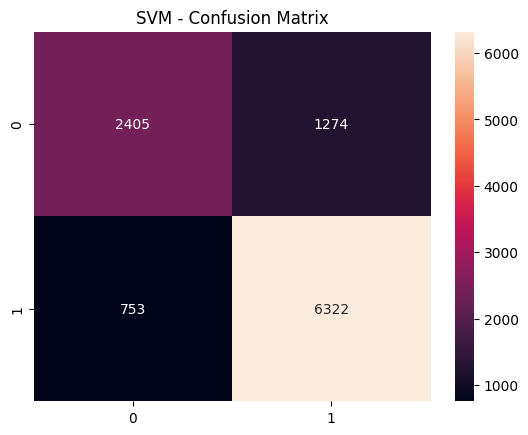

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM - Confusion Matrix")
plt.show()

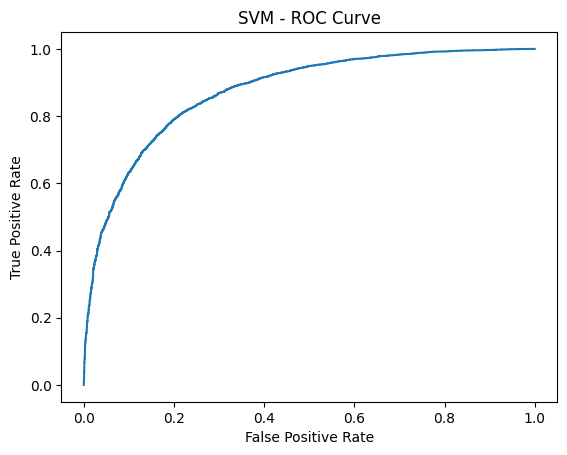

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
plt.figure()
plt.plot(fpr, tpr)
plt.title("SVM - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
# Random Forest
model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [ ]:
y_pred_rf = model_rf.predict(X_test_tfidf)
y_prob_rf = model_rf.predict_proba(X_test_tfidf)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8105821089827041


In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.8829283191680025


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.54      0.66      3679
           1       0.80      0.95      0.87      7075

    accuracy                           0.81     10754
   macro avg       0.83      0.74      0.76     10754
weighted avg       0.82      0.81      0.80     10754



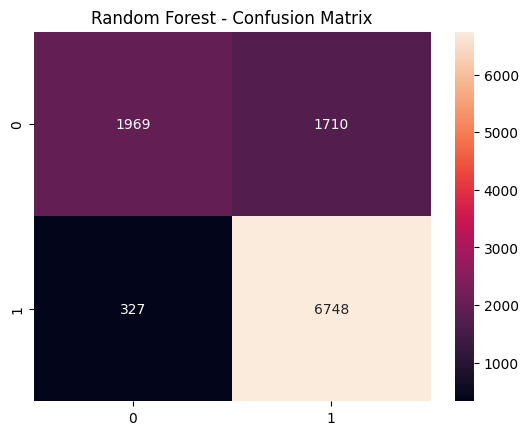

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest - Confusion Matrix")
plt.show()

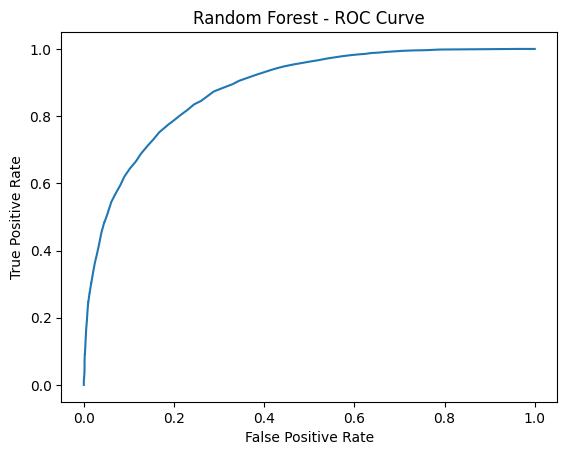

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure()
plt.plot(fpr, tpr)
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

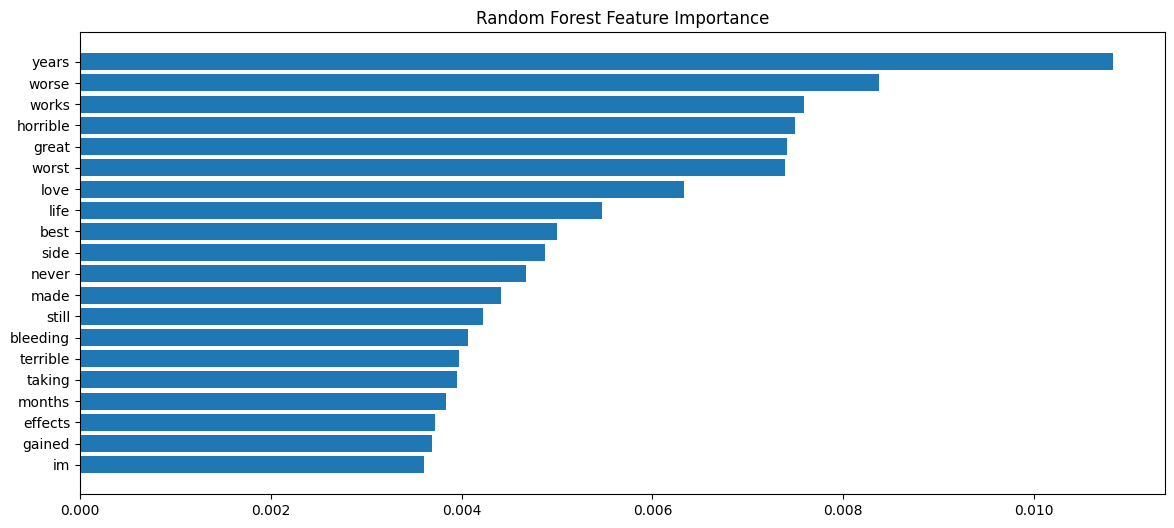

In [ ]:
# Random Forest Feature Importance
importances_rf = model_rf.feature_importances_
indices_rf = np.argsort(importances_rf)[-20:]

plt.figure(figsize=(14,6))
plt.barh(feature_names[indices_rf], importances_rf[indices_rf])
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
# XGBoost
model_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:04:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = model_xgb.predict(X_test_tfidf)
y_prob_xgb = model_xgb.predict_proba(X_test_tfidf)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.7943090942904966


In [ ]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC: 0.8577144273149966


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.77      0.56      0.65      3679
           1       0.80      0.91      0.85      7075

    accuracy                           0.79     10754
   macro avg       0.79      0.74      0.75     10754
weighted avg       0.79      0.79      0.78     10754



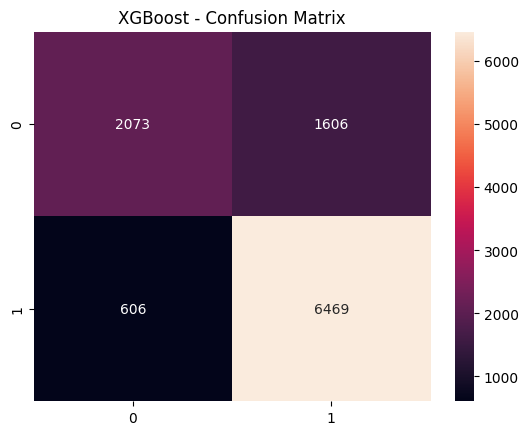

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost - Confusion Matrix")
plt.show()

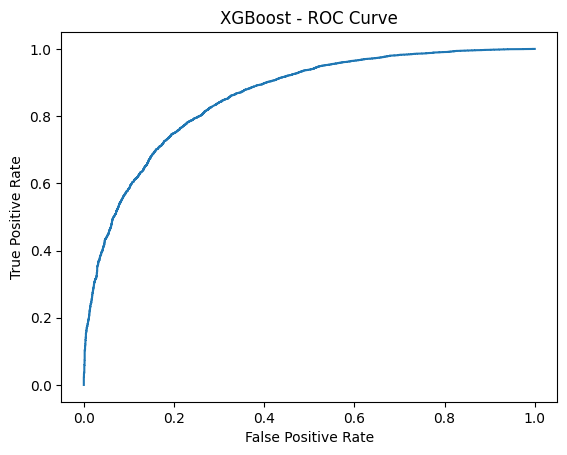

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
plt.figure()
plt.plot(fpr, tpr)
plt.title("XGBoost - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

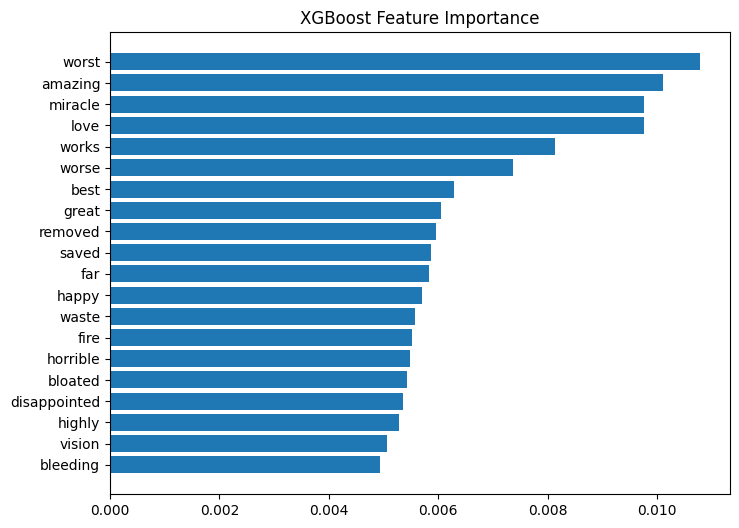

In [ ]:
# XGBoost Feature Importance
importances_xgb = model_xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[-20:]

plt.figure(figsize=(8,6))
plt.barh(feature_names[indices_xgb], importances_xgb[indices_xgb])
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
# Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = model_nb.predict(X_test_tfidf)
y_prob_nb = model_nb.predict_proba(X_test_tfidf)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.7730146922075507


In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.82      0.43      0.57      3679
           1       0.76      0.95      0.85      7075

    accuracy                           0.77     10754
   macro avg       0.79      0.69      0.71     10754
weighted avg       0.78      0.77      0.75     10754



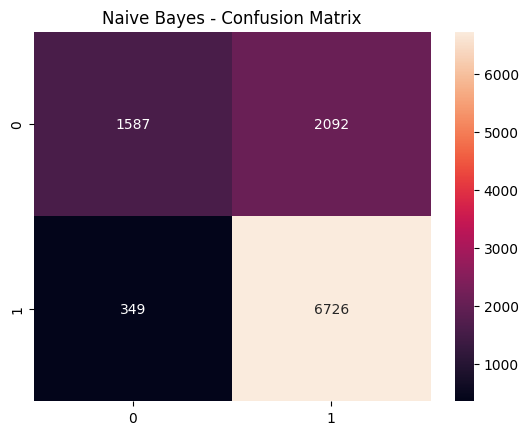

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

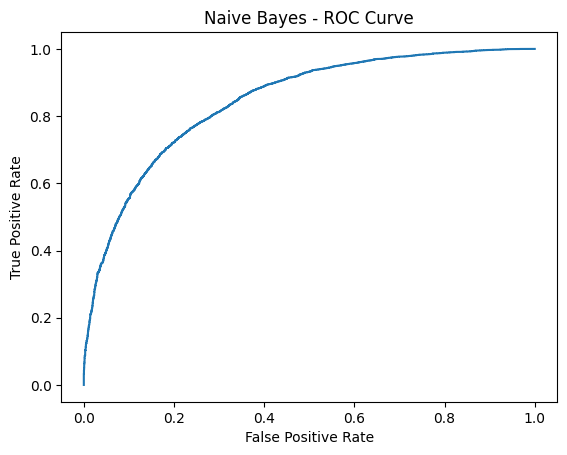

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
plt.figure()
plt.plot(fpr, tpr)
plt.title("Naive Bayes - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
# Comparison Table
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb)
}

for model, score in results.items():
    print(model, "Accuracy:", score)

Logistic Regression Accuracy: 0.8156964850288265
SVM Accuracy: 0.8115119955365445
Random Forest Accuracy: 0.8105821089827041
XGBoost Accuracy: 0.7943090942904966
Naive Bayes Accuracy: 0.7730146922075507


In [ ]:
# Tokenization for LSTM
max_words = 10000
max_len = 200
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [ ]:
# Building LSTM Model
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
lstm_model.add(LSTM(64, return_sequences=False))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compile Model
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train Model
lstm_model.fit(X_train_pad, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
538/538 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7845 - loss: 0.4670 - val_accuracy: 0.8130 - val_loss: 0.4166
Epoch 2/3
538/538 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8507 - loss: 0.3507 - val_accuracy: 0.8131 - val_loss: 0.4197
Epoch 3/3
538/538 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8826 - loss: 0.2885 - val_accuracy: 0.8154 - val_loss: 0.4501


In [ ]:
# Predictions
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
# Evaluation
print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))

LSTM Accuracy: 0.8118839501580807
              precision    recall  f1-score   support

           0       0.75      0.67      0.71      3679
           1       0.84      0.89      0.86      7075

    accuracy                           0.81     10754
   macro avg       0.80      0.78      0.78     10754
weighted avg       0.81      0.81      0.81     10754



#Tokenization and  Stemming and Lemmatization

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    # Applying Stemming
    stemmed = [stemmer.stem(word) for word in tokens]
    # Applying Lemmatization
    lemmatized = [lemmatizer.lemmatize(word) for word in stemmed]
    return " ".join(lemmatized)

In [ ]:
# Apply preprocessing
X = df['review'].apply(preprocess_text)
y = df['rating'] > 5
y = y.astype(int)

# Word2Vec

In [ ]:
# Tokenize for Word2Vec
sentences = [text.split() for text in X]
# Train Word2Vec model
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

In [ ]:
# Converting sentence to vector
def get_avg_vector(words, model, size):
    vec = np.zeros(size)
    count = 0
    for word in words:
        if word in model.wv:
            vec += model.wv[word]
            count += 1
    return vec / count if count != 0 else vec
X_w2v = np.array([get_avg_vector(text.split(), w2v_model, 100) for text in X])

In [ ]:
# Train-test split
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

In [ ]:
# Train model on Word2Vec features
model_w2v = LogisticRegression()
model_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = model_w2v.predict(X_test_w2v)
print("Word2Vec Accuracy:", accuracy_score(y_test_w2v, y_pred_w2v))

Word2Vec Accuracy: 0.7841733308536358


#BERT

In [ ]:
sample_size = 3000
X_small = X[:sample_size]
y_small = y[:sample_size]

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def encode_data(texts, tokenizer, max_len=64):
  train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
for batch in train_loader:
    input_ids, attention_mask, labels = [b.to(device) for b in batch]

    outputs = bert_model(input_ids=input_ids,
                         attention_mask=attention_mask,
                         labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
test_dataset = TensorDataset(X_test_ids, X_test_mask)
test_loader = DataLoader(test_dataset, batch_size=8)
bert_model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask = [b.to(device) for b in batch]
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
y_pred_bert = np.array(predictions)
print("BERT Accuracy:", accuracy_score(y_test_bert, y_pred_bert))

BERT Accuracy: 0.30044634554584343


In [ ]:
# Accuracies

accuracies = {}

# Adding Word2Vec
accuracies["Word2Vec"] = accuracy_score(y_test_w2v, y_pred_w2v)

# Adding BERT
accuracies["BERT"] = accuracy_score(y_test_bert, y_pred_bert)

# Print results
print("\nUpdated Accuracy Scores:")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.4f}")


Updated Accuracy Scores:
Word2Vec: 0.7842
BERT: 0.3004


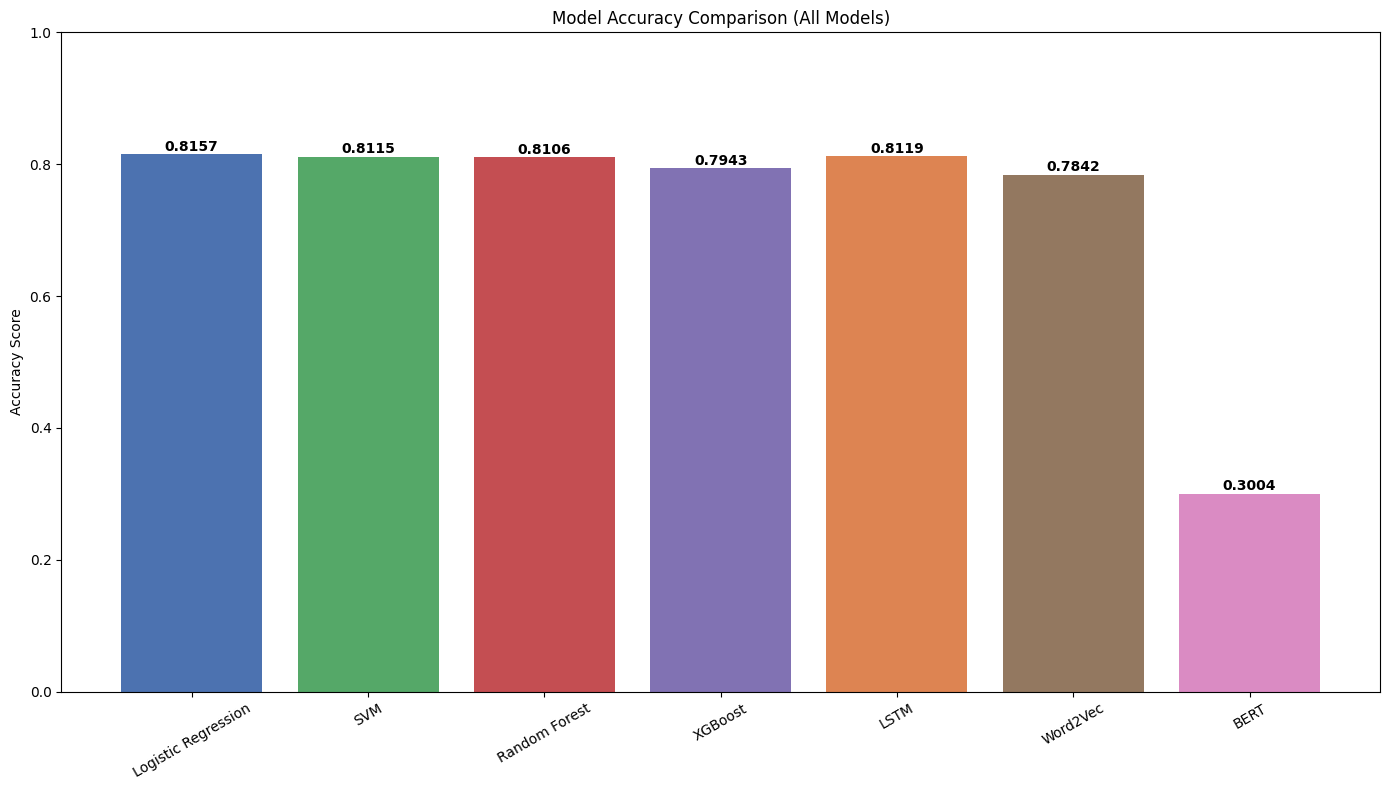

Accuracy Scores:
Logistic Regression: 0.8157
SVM: 0.8115
Random Forest: 0.8106
XGBoost: 0.7943
LSTM: 0.8119
Word2Vec: 0.7842
BERT: 0.3004


In [ ]:
#comparision
models = {
    "Logistic Regression": model_lr,
    "SVM": model_svm,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

accuracies = {}

for name, mdl in models.items():
    y_pred = mdl.predict(X_test_tfidf)
    accuracies[name] = accuracy_score(y_test, y_pred)

accuracies["LSTM"] = accuracy_score(y_test, y_pred_lstm)

accuracies["Word2Vec"] = accuracy_score(y_test_w2v, y_pred_w2v)

accuracies["BERT"] = accuracy_score(y_test_bert, y_pred_bert)

model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

plt.figure(figsize=(14,8))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#DD8452', '#937860', '#DA8BC3']

bars = plt.bar(model_names, accuracy_values, color=colors)

plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison (All Models)")
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.4f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Accuracy Scores:")
for name, acc in accuracies.items():
    print(f"{name}: {acc:.4f}")

337/337 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


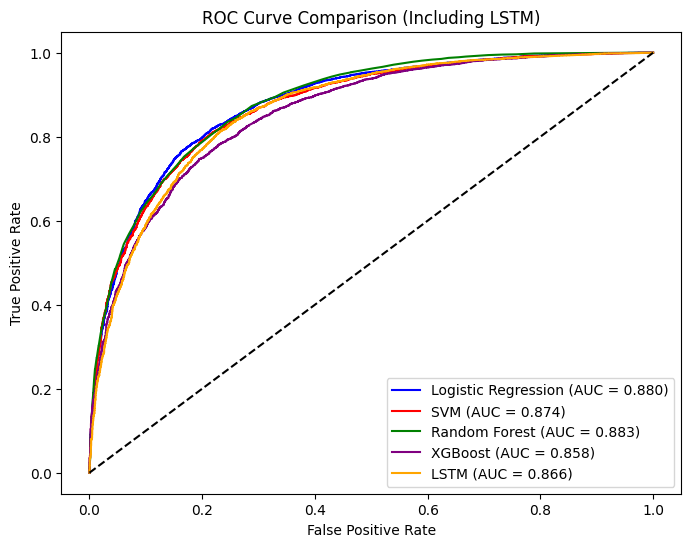

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

colors = ['blue','red','green','purple']

for (name, model), color in zip(models.items(), colors):

    y_prob = model.predict_proba(X_test_tfidf)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color,
             label=f"{name} (AUC = {roc_auc:.3f})")

y_prob_lstm = lstm_model.predict(X_test_pad).ravel()

fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.plot(fpr_lstm, tpr_lstm, color='orange',
         label=f"LSTM (AUC = {roc_auc_lstm:.3f})")

# Random line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Including LSTM)")
plt.legend()
plt.show()